# CMPT 413 / 713 Tutorial 5
## Text Classification using pretrained word vectors

In [2]:
# Load the AG NEWS dataset from the torchtext library (The same to before)
import torch
import torchtext

train_dataset, val_dataset = torchtext.datasets.AG_NEWS()
target_classes = ["World", "Sports", "Business", "Sci/Tec"]

## Basic preprocessing of text (The same to last tutorial)

In [4]:
# Some basic preprocessing of text dataset
import io
import nltk
import string
import numpy as np
from tqdm import tqdm
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
  
stemmer = PorterStemmer()

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

# Function to remove punctuation
def remove_punctuation(text):
    punctuationfree="".join([i for i in text if i not in string.punctuation])
    return punctuationfree

# Function to tokenize text
def tokenization(text):
    tokens = word_tokenize(text)
    return tokens

# Stem function for the words
def stem(text):
    stem_text = [stemmer.stem(word) for word in text]
    return stem_text

train_text = [data[1] for data in train_dataset]
val_text = [data[1] for data in val_dataset]

train_len = []
val_len = []

train_labels = np.array([item[0] for item in train_dataset]) - 1
val_labels = np.array([item[0] for item in val_dataset]) - 1

for i in tqdm(range(len(train_text))):
    train_text[i] = train_text[i].lower()
    train_text[i] = remove_punctuation(train_text[i])
    train_text[i] = tokenization(train_text[i])
    train_text[i] = stem(train_text[i])
    train_len.append(len(train_text[i]))
    
for i in tqdm(range(len(val_text))):
    val_text[i] = val_text[i].lower()
    val_text[i] = remove_punctuation(val_text[i])
    val_text[i] = tokenization(val_text[i])
    val_text[i] = stem(val_text[i])
    val_len.append(len(val_text[i]))
    
train_len = np.array(train_len)
val_len = np.array(val_len)

[nltk_data] Downloading package punkt to /Users/shawn/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/shawn/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/shawn/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/shawn/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
100%|██████████| 7600/7600 [00:05<00:00, 1475.86it/s]


## Download the pretrained word embeddings
### 1. Download the word embeddings of Word2Vec
### 2. Download the word embeddings of Glove

In [7]:
import gensim.downloader as api
embed_w2v = api.load('word2vec-google-news-300')
embed_glove = api.load("glove-twitter-25")
# print("Word2Vec embedding of 'love'", embed_w2v["love"])
print("Number of words in word2vec", len(embed_w2v.index_to_key))
print("length of the embedding of word2vec", len(embed_w2v["love"]))

# print("Glove embedding of 'love'", embed_glove["love"])
print("Number of words in glove", len(embed_glove.index_to_key))
print("length of the embedding of glove", len(embed_glove["love"]))

Number of words in word2vec 3000000
length of the embedding of word2vec 300
Number of words in glove 1193514
length of the embedding of glove 25


## Custom Dataset Loader
### 1. Converts words to the pretrained embeddings (word2vec, glove)
### 2. Calculate the sentence embeddings based on the average word embeddings


In [23]:
# Custom dataset loader
from torch.utils.data import Dataset, DataLoader

class TextDataset(Dataset):
    def __init__(self, text_dataset, labels):
        super(TextDataset, self).__init__()
        self.text_dataset = text_dataset
        self.labels = labels

    def __len__(self):
        return len(self.text_dataset)

    def __getitem__(self, idx):
        text = self.text_dataset[idx]
        label = self.labels[idx]
        tokens_w2v = []
        tokens_glove = []
        
        for counter in range(len(text)):
            if text[counter] in embed_w2v:
                tokens_w2v.append(embed_w2v[text[counter]])

        for counter in range(len(text)):
            if text[counter] in embed_glove:
                tokens_glove.append(embed_glove[text[counter]])
        
        sent_w2v = np.array(tokens_w2v).mean(0)
        sent_glove = np.array(tokens_glove).mean(0)

        return (sent_w2v, sent_glove), label
    
train_dataset = TextDataset(train_text, train_labels)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

val_dataset = TextDataset(val_text, val_labels)
val_dataloader = DataLoader(val_dataset, batch_size=32, num_workers=0)


## Define Neural Network
### We don't need to have the embedding layer, instead, we just need the FCN to predict the labels for the sentences
### Crete two classifiers with word2vec or glove embeddings

In [28]:
from torch import nn
from torch.optim import Adam
from torch.nn import functional as F
from sklearn.metrics import accuracy_score

class TextClassifier_W2V(nn.Module):
    def __init__(self):
        super(TextClassifier_W2V, self).__init__()
        self.seq = nn.Sequential(
            nn.Linear(300, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        logits = self.seq(x)
        return logits

class TextClassifier_GLOVE(nn.Module):
    def __init__(self):
        super(TextClassifier_GLOVE, self).__init__()
        self.seq = nn.Sequential(
            nn.Linear(25, 16),
            nn.ReLU(),
            nn.Linear(16, 4)
        )

    def forward(self, x):
        logits = self.seq(x)
        return logits


    
classifier_w2v = TextClassifier_W2V()
classifier_glove = TextClassifier_GLOVE()

## Train the classifier_w2v

In [32]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(classifier_w2v.parameters(), lr=0.0001)
def cal_loss_and_accuracy(model, loss_fn, val_data_loader):
    with torch.no_grad():
        y_actual, y_preds, losses = [],[],[]
        for x, y in val_data_loader:
            preds = model(x[0])
            loss = loss_fn(preds, y)
            losses.append(loss.item())
            y_actual.append(y)
            y_preds.append(preds.argmax(dim=-1))

        y_actual = torch.cat(y_actual)
        y_preds = torch.cat(y_preds)

        print("Val Loss : {:.3f}".format(torch.tensor(losses).mean()))
        print("Val Accuracy  : {:.3f}".format(accuracy_score(y_actual.cpu().numpy(), y_preds.cpu().numpy())))

# train the model 5 epochs
for i in range(5):
    losses = []
    for x, y in tqdm(train_dataloader):
        
        # forward
        y_preds = classifier_w2v(x[0])
        
        # calculate losses
        loss = loss_fn(y_preds, y)
        losses.append(loss.item())
        
        # empty old gradients
        optimizer.zero_grad()
        
        # calculate gradients and backward
        loss.backward()
        
        # update all parameters
        optimizer.step()

    print("Train Loss : {:.3f}".format(torch.tensor(losses).mean()))
    cal_loss_and_accuracy(classifier_w2v, loss_fn, val_dataloader)

100%|██████████| 3750/3750 [00:29<00:00, 125.96it/s]


Train Loss : 0.583
Val Loss : 0.429
Val Accuracy  : 0.856


100%|██████████| 3750/3750 [00:28<00:00, 133.14it/s]


Train Loss : 0.398
Val Loss : 0.401
Val Accuracy  : 0.862


100%|██████████| 3750/3750 [00:28<00:00, 132.31it/s]


Train Loss : 0.380
Val Loss : 0.394
Val Accuracy  : 0.864


100%|██████████| 3750/3750 [00:28<00:00, 132.13it/s]


Train Loss : 0.372
Val Loss : 0.386
Val Accuracy  : 0.866


100%|██████████| 3750/3750 [00:28<00:00, 132.86it/s]


Train Loss : 0.366
Val Loss : 0.382
Val Accuracy  : 0.867


## Train the classifier_glove

In [29]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(classifier_glove.parameters(), lr=0.0001)
def cal_loss_and_accuracy(model, loss_fn, val_data_loader):
    with torch.no_grad():
        y_actual, y_preds, losses = [],[],[]
        for x, y in val_data_loader:
            preds = model(x[1])
            loss = loss_fn(preds, y)
            losses.append(loss.item())
            y_actual.append(y)
            y_preds.append(preds.argmax(dim=-1))

        y_actual = torch.cat(y_actual)
        y_preds = torch.cat(y_preds)

        print("Val Loss : {:.3f}".format(torch.tensor(losses).mean()))
        print("Val Accuracy  : {:.3f}".format(accuracy_score(y_actual.cpu().numpy(), y_preds.cpu().numpy())))

# train the model 5 epochs
for i in range(5):
    losses = []
    for x, y in tqdm(train_dataloader):
        
        # forward
        y_preds = classifier_glove(x[1])
        
        # calculate losses
        loss = loss_fn(y_preds, y)
        losses.append(loss.item())
        
        # empty old gradients
        optimizer.zero_grad()
        
        # calculate gradients and backward
        loss.backward()
        
        # update all parameters
        optimizer.step()

    print("Train Loss : {:.3f}".format(torch.tensor(losses).mean()))
    cal_loss_and_accuracy(classifier_glove, loss_fn, val_dataloader)

100%|██████████| 3750/3750 [00:22<00:00, 167.92it/s]


Train Loss : 1.178
Val Loss : 0.912
Val Accuracy  : 0.741


100%|██████████| 3750/3750 [00:22<00:00, 169.36it/s]


Train Loss : 0.756
Val Loss : 0.668
Val Accuracy  : 0.776


100%|██████████| 3750/3750 [00:22<00:00, 168.56it/s]


Train Loss : 0.624
Val Loss : 0.607
Val Accuracy  : 0.781


100%|██████████| 3750/3750 [00:22<00:00, 163.89it/s]


Train Loss : 0.587
Val Loss : 0.587
Val Accuracy  : 0.783


100%|██████████| 3750/3750 [00:22<00:00, 168.77it/s]


Train Loss : 0.574
Val Loss : 0.579
Val Accuracy  : 0.788


# Evaluation for the word2vec model and glove model

In [33]:
from sklearn.metrics import classification_report

y_actual, y_preds = [], []

# test the model of w2v
with torch.no_grad():
    for x, y in val_dataloader:
        preds = classifier_w2v(x[0])
        y_preds.append(preds)
        y_actual.append(y)
    
    y_preds, y_actual = torch.cat(y_preds), torch.cat(y_actual)
    
    y_actual = y_actual.cpu().numpy()
    y_preds = F.softmax(y_preds, dim=-1).argmax(dim=-1).cpu().numpy()
    
# print results
print("Accuracy of w2v : {}".format(accuracy_score(y_actual, y_preds)))
print("\nClassification Report of w2v: ")
print(classification_report(y_actual, y_preds, target_names=target_classes))

y_actual, y_preds = [], []

# test the model of glove
with torch.no_grad():
    for x, y in val_dataloader:
        preds = classifier_glove(x[1])
        y_preds.append(preds)
        y_actual.append(y)
    
    y_preds, y_actual = torch.cat(y_preds), torch.cat(y_actual)
    
    y_actual = y_actual.cpu().numpy()
    y_preds = F.softmax(y_preds, dim=-1).argmax(dim=-1).cpu().numpy()
    
# print results
print("Accuracy of glove : {}".format(accuracy_score(y_actual, y_preds)))
print("\nClassification Report of glove: ")
print(classification_report(y_actual, y_preds, target_names=target_classes))

Accuracy of w2v : 0.866578947368421

Classification Report of w2v: 
              precision    recall  f1-score   support

       World       0.89      0.86      0.87      1900
      Sports       0.93      0.95      0.94      1900
    Business       0.82      0.82      0.82      1900
     Sci/Tec       0.83      0.84      0.84      1900

    accuracy                           0.87      7600
   macro avg       0.87      0.87      0.87      7600
weighted avg       0.87      0.87      0.87      7600

Accuracy of glove : 0.7884210526315789

Classification Report of glove: 
              precision    recall  f1-score   support

       World       0.80      0.81      0.80      1900
      Sports       0.88      0.91      0.89      1900
    Business       0.73      0.70      0.71      1900
     Sci/Tec       0.74      0.75      0.75      1900

    accuracy                           0.79      7600
   macro avg       0.79      0.79      0.79      7600
weighted avg       0.79      0.79      0.79 

## Visualizing the word embeddings of word2vec
### Here we use TSNE to project sentence vectors onto 2 dimensions and plot the results.
### It can been seen that some regions forming for each of the classes.

(7600, 2)


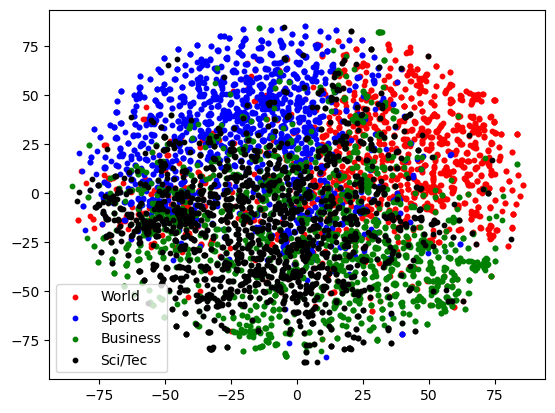

In [37]:
from sklearn.manifold import TSNE
from matplotlib import pyplot as plt

embeddings = []
y_gt = []

with torch.no_grad():
    for x, y in val_dataloader:
        embeddings.append(x[0].detach().cpu().numpy())
        y_gt.append(y)
embeddings = np.concatenate(embeddings, 0)
y_gt = np.concatenate(y_gt, 0)

X_embedded = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=3).fit_transform(embeddings)
cdict = {0: 'red', 1: 'blue', 2: 'green', 3: 'black'}


fig, ax = plt.subplots()
for g in np.unique(y_gt):
    ix = np.where(y_gt == g)
    ax.scatter(X_embedded[ix[0]][:, 0], X_embedded[ix[0]][:, 1], c = cdict[g], label = target_classes[g], s = 10)
ax.legend()
plt.show()

## Visualizing the word embeddings of glove
### Here we use TSNE to project sentence vectors onto 2 dimensions and plot the results.
### It can been seen that some regions forming forming for each of the classes.

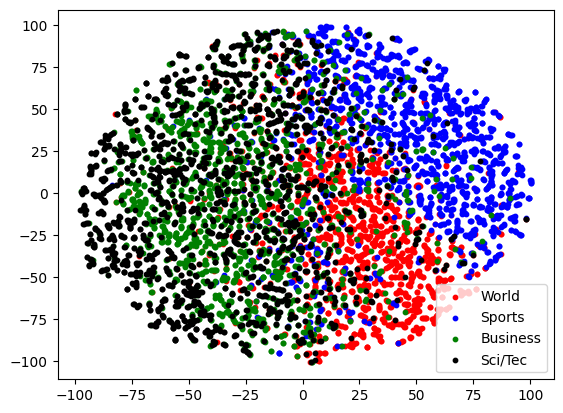

In [30]:
from sklearn.manifold import TSNE
from matplotlib import pyplot as plt

embeddings = []
y_gt = []

with torch.no_grad():
    for x, y in val_dataloader:
        embeddings.append(x[1].detach().cpu().numpy())
        y_gt.append(y)
embeddings = np.concatenate(embeddings, 0)
y_gt = np.concatenate(y_gt, 0)

X_embedded = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=3).fit_transform(embeddings)
cdict = {0: 'red', 1: 'blue', 2: 'green', 3: 'black'}


fig, ax = plt.subplots()
for g in np.unique(y_gt):
    ix = np.where(y_gt == g)
    ax.scatter(X_embedded[ix[0]][:, 0], X_embedded[ix[0]][:, 1], c = cdict[g], label = target_classes[g], s = 10)
ax.legend()
plt.show()

# What we can do to improve the word embeddings
### We can try combining the learned word embeddings with the pretrained word embeddings

In [38]:
# Get word to number mapping for word counts that are over 10
from collections import Counter

counter = Counter()
for sentence in tqdm(train_text):
    counter.update(sentence)
# Here we only get words that appears more than 10 times
counter = Counter({k: c for k, c in counter.items() if c >= 10})
vocab = list(counter.keys())

vocab_to_id = {}
vocab_to_id['<PAD>'] = 0
vocab_to_id['<UNK>'] = 1

counter = 2
for word in vocab:
    vocab_to_id[word] = counter
    counter += 1
vocab_size = counter
print('Vocab Size:', counter)

# Custom dataset loader
from torch.utils.data import Dataset, DataLoader

class TextDataset(Dataset):
    def __init__(self, text_dataset, labels, vocab_to_id, len_thresh=50):
        super(TextDataset, self).__init__()
        self.text_dataset = text_dataset
        self.labels = labels
        self.vocab_to_id = vocab_to_id
        self.len_thresh = len_thresh

    def __len__(self):
        return len(self.text_dataset)

    def __getitem__(self, idx):
        text = self.text_dataset[idx]
        label = self.labels[idx]
        tokens = []
        
        for counter in range(len(text)):
            if counter == self.len_thresh:
                break
            
            if text[counter] in self.vocab_to_id.keys():
                tokens.append(self.vocab_to_id[text[counter]])
            else:
                tokens.append(vocab_to_id['<UNK>'])
                
        while counter + 1 < self.len_thresh:
            tokens.append(vocab_to_id['<PAD>'])
            counter += 1

        tokens_w2v = []
        for counter in range(len(text)):
            if text[counter] in embed_w2v:
                tokens_w2v.append(embed_w2v[text[counter]])
        sent_w2v = np.array(tokens_w2v).mean(0)

        return (np.array(tokens), sent_w2v), label
    
train_dataset = TextDataset(train_text, train_labels, vocab_to_id)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

val_dataset = TextDataset(val_text, val_labels, vocab_to_id)
val_dataloader = DataLoader(val_dataset, batch_size=32, num_workers=0)

from torch import nn
from torch.optim import Adam
from torch.nn import functional as F
from sklearn.metrics import accuracy_score

class TextClassifier(nn.Module):
    def __init__(self):
        super(TextClassifier, self).__init__()
        self.embedding_layer = nn.Embedding(vocab_size, 256, padding_idx=0)
        self.seq = nn.Sequential(
            nn.Linear(556, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        embeddings = self.embedding_layer(x[0])
        # We take the mean of text embeddings to get a sentence vector
        embeddings = embeddings.mean(1)
        logits = self.seq(torch.cat((embeddings, x[1]), 1))
        return logits

classifier = TextClassifier()

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(classifier.parameters(), lr=0.0001)
def cal_loss_and_accuracy(model, loss_fn, val_data_loader):
    with torch.no_grad():
        y_actual, y_preds, losses = [],[],[]
        for x, y in val_data_loader:
            preds = model(x)
            loss = loss_fn(preds, y)
            losses.append(loss.item())
            y_actual.append(y)
            y_preds.append(preds.argmax(dim=-1))

        y_actual = torch.cat(y_actual)
        y_preds = torch.cat(y_preds)

        print("Val Loss : {:.3f}".format(torch.tensor(losses).mean()))
        print("Val Accuracy  : {:.3f}".format(accuracy_score(y_actual.cpu().numpy(), y_preds.cpu().numpy())))

# train the model 5 epochs
for i in range(5):
    losses = []
    for x, y in tqdm(train_dataloader):
        
        # forward
        y_preds = classifier(x)
        
        # calculate losses
        loss = loss_fn(y_preds, y)
        losses.append(loss.item())
        
        # empty old gradients
        optimizer.zero_grad()
        
        # calculate gradients and backward
        loss.backward()
        
        # update all parameters
        optimizer.step()

    print("Train Loss : {:.3f}".format(torch.tensor(losses).mean()))
    cal_loss_and_accuracy(classifier, loss_fn, val_dataloader)

100%|██████████| 120000/120000 [00:00<00:00, 163216.20it/s]


Vocab Size: 15089


100%|██████████| 3750/3750 [01:10<00:00, 53.16it/s]


Train Loss : 0.516
Val Loss : 0.367
Val Accuracy  : 0.874


100%|██████████| 3750/3750 [01:10<00:00, 52.86it/s]


...

Train Loss : 0.295
Val Loss : 0.307
Val Accuracy  : 0.892


100%|██████████| 3750/3750 [01:07<00:00, 55.96it/s]


Train Loss : 0.272
Val Loss : 0.293
Val Accuracy  : 0.899


100%|██████████| 3750/3750 [01:11<00:00, 52.20it/s]


Train Loss : 0.255
Val Loss : 0.286
Val Accuracy  : 0.902
